# 01 — EDA
Load resumes + jobs, inspect shape, categories, and missing values.

## Objective

The purpose of this notebook is to explore and understand the processed datasets before feature engineering and model development.

The analysis focuses on:

- Resume Dataset
- Job Dataset
- Job Corpus

This notebook helps identify:

- Data distribution
- Category balance
- Text characteristics
- Job trends
- Frequently occurring skills
- Company and location statistics

The insights obtained from this analysis will guide feature engineering and machine learning model development.

In [1]:
# ============================================================
# Import Required Libraries
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# Plot Settings
plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (10, 6)

Matplotlib is building the font cache; this may take a moment.


In [2]:
# ============================================================
# Load Processed Datasets
# ============================================================

PROJECT_ROOT = Path("..")

PROCESSED_DATA = PROJECT_ROOT / "data" / "processed"
INTERIM_DATA = PROJECT_ROOT / "data" / "interim"

resumes_df = pd.read_csv(PROCESSED_DATA / "resumes_clean.csv")
jobs_df = pd.read_csv(PROCESSED_DATA / "jobs_clean.csv")
corpus_df = pd.read_csv(INTERIM_DATA / "job_corpus.csv")

print("Datasets loaded successfully!")

Datasets loaded successfully!


In [3]:
# ============================================================
# Dataset Overview
# ============================================================

overview = pd.DataFrame({
    "Dataset": ["Resume", "Jobs", "Job Corpus"],
    "Rows": [
        resumes_df.shape[0],
        jobs_df.shape[0],
        corpus_df.shape[0]
    ],
    "Columns": [
        resumes_df.shape[1],
        jobs_df.shape[1],
        corpus_df.shape[1]
    ]
})

display(overview)

,Dataset,Rows,Columns
0,Resume,962,2
1,Jobs,136759,8
2,Job Corpus,136759,7


In [4]:
# ============================================================
# Resume Category Statistics
# ============================================================

category_counts = resumes_df["Category"].value_counts()

print(f"Total Resume Categories : {resumes_df['Category'].nunique()}")
print(f"Total Resumes           : {len(resumes_df)}")

display(category_counts)

Total Resume Categories : 25
Total Resumes           : 962


Category
Java Developer               84
Testing                      70
DevOps Engineer              55
Python Developer             48
Web Designing                45
HR                           44
Hadoop                       42
Data Science                 40
Mechanical Engineer          40
Sales                        40
Operations Manager           40
ETL Developer                40
Blockchain                   40
Arts                         36
Database                     33
Health and fitness           30
Electrical Engineering       30
PMO                          30
Business Analyst             28
DotNet Developer             28
Automation Testing           26
Network Security Engineer    25
Civil Engineer               24
SAP Developer                24
Advocate                     20
Name: count, dtype: int64

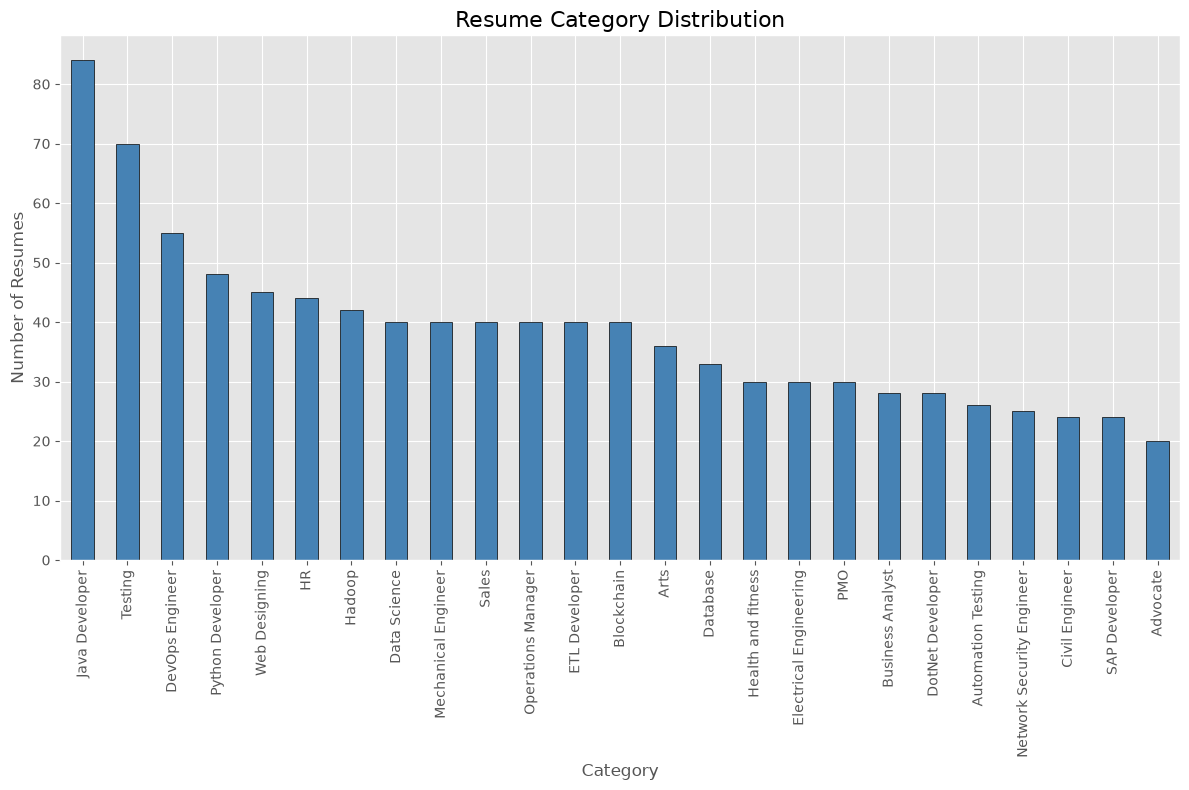

In [5]:
# ============================================================
# Resume Category Distribution
# ============================================================

plt.figure(figsize=(12,8))

category_counts.plot(
    kind="bar",
    color="steelblue",
    edgecolor="black"
)

plt.title("Resume Category Distribution", fontsize=16)
plt.xlabel("Category")
plt.ylabel("Number of Resumes")

plt.xticks(rotation=90)

plt.tight_layout()

plt.show()

In [6]:
# ============================================================
# Category Percentage Distribution
# ============================================================

category_percentage = (
    resumes_df["Category"]
    .value_counts(normalize=True)
    * 100
)

display(category_percentage.round(2))

Category
Java Developer               8.73
Testing                      7.28
DevOps Engineer              5.72
Python Developer             4.99
Web Designing                4.68
HR                           4.57
Hadoop                       4.37
Data Science                 4.16
Mechanical Engineer          4.16
Sales                        4.16
Operations Manager           4.16
ETL Developer                4.16
Blockchain                   4.16
Arts                         3.74
Database                     3.43
Health and fitness           3.12
Electrical Engineering       3.12
PMO                          3.12
Business Analyst             2.91
DotNet Developer             2.91
Automation Testing           2.70
Network Security Engineer    2.60
Civil Engineer               2.49
SAP Developer                2.49
Advocate                     2.08
Name: proportion, dtype: float64

## Key Observations

- The resume dataset contains **25 unique job categories**.
- Every resume belongs to exactly one category.
- Category distribution will help identify class imbalance before training the classifier.
- A balanced class distribution generally improves classification performance.
- The resume dataset is suitable for supervised text classification.

## Resume Text Length Analysis

This section analyzes the length of resume text.

Understanding text length helps identify:

- Extremely short resumes
- Extremely long resumes
- Average document size

These insights are useful before feature extraction using TF-IDF.

In [7]:
# ============================================================
# Resume Text Length Analysis
# ============================================================

resumes_df["text_length"] = resumes_df["text"].str.len()

display(resumes_df["text_length"].describe())

count      962.000000
mean      2938.002079
std       2719.114990
min        118.000000
25%       1135.000000
50%       2153.000000
75%       3675.000000
max      13847.000000
Name: text_length, dtype: float64

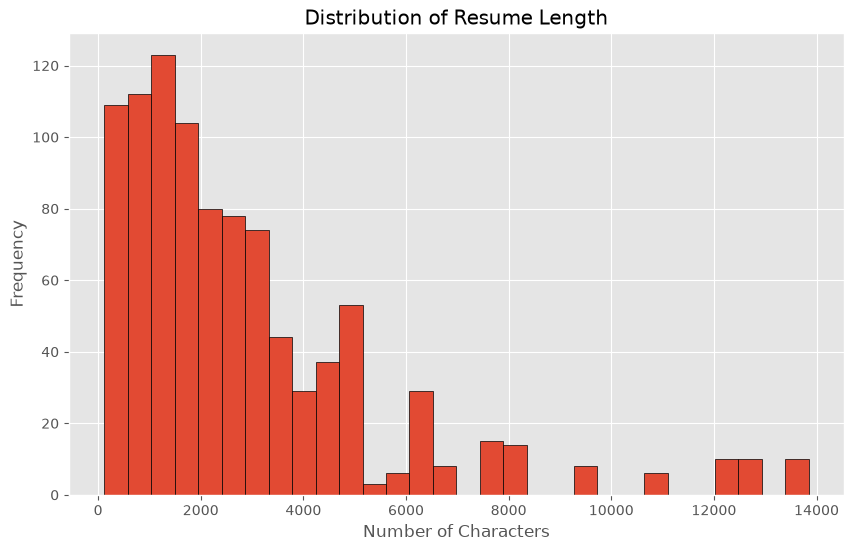

In [8]:
# ============================================================
# Distribution of Resume Length
# ============================================================

plt.figure(figsize=(10,6))

plt.hist(
    resumes_df["text_length"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Resume Length")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")

plt.show()

## Jobs Dataset Analysis

This section explores the processed job dataset.

The objectives are to understand:

- Job distribution
- Hiring companies
- Hiring locations
- Required experience
- Frequently occurring skills

These insights help understand the job market and improve the recommendation system.

In [9]:
# ============================================================
# Jobs Dataset Statistics
# ============================================================

print(f"Total Jobs            : {len(jobs_df)}")
print(f"Unique Companies      : {jobs_df['company'].nunique()}")
print(f"Unique Locations      : {jobs_df['location'].nunique()}")
print(f"Unique Experience     : {jobs_df['experience'].nunique()}")

Total Jobs            : 136759
Unique Companies      : 32845
Unique Locations      : 10855
Unique Experience     : 152


In [10]:
# ============================================================
# Top Hiring Companies
# ============================================================

top_companies = jobs_df["company"].value_counts().head(10)

display(top_companies)

company
The Job Network                          934
Confidential                             568
Lowe's Companies, Inc.                   518
TEKsystems                               487
Capital One                              439
Dice                                     412
Insight Global                           402
Indian Institute of Technology Bombay    401
Wells Fargo                              375
J. Galt                                  360
Name: count, dtype: int64

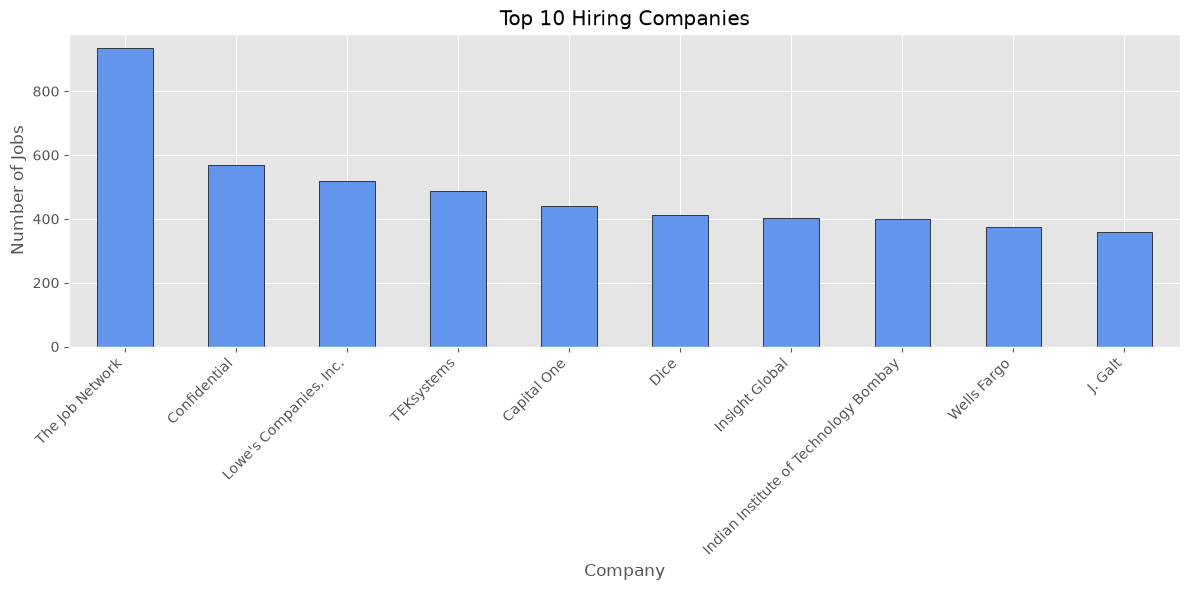

In [11]:
plt.figure(figsize=(12,6))

top_companies.plot(
    kind="bar",
    color="cornflowerblue",
    edgecolor="black"
)

plt.title("Top 10 Hiring Companies")
plt.xlabel("Company")
plt.ylabel("Number of Jobs")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.show()

In [12]:
# ============================================================
# Top Hiring Locations
# ============================================================

top_locations = jobs_df["location"].value_counts().head(10)

display(top_locations)

location
United States          7541
Bengaluru/Bangalore    3687
New York, NY           2639
Mumbai                 2296
Chicago, IL            1763
Houston, TX            1653
Bengaluru              1425
Dallas, TX             1309
Atlanta, GA            1297
Chennai                1184
Name: count, dtype: int64

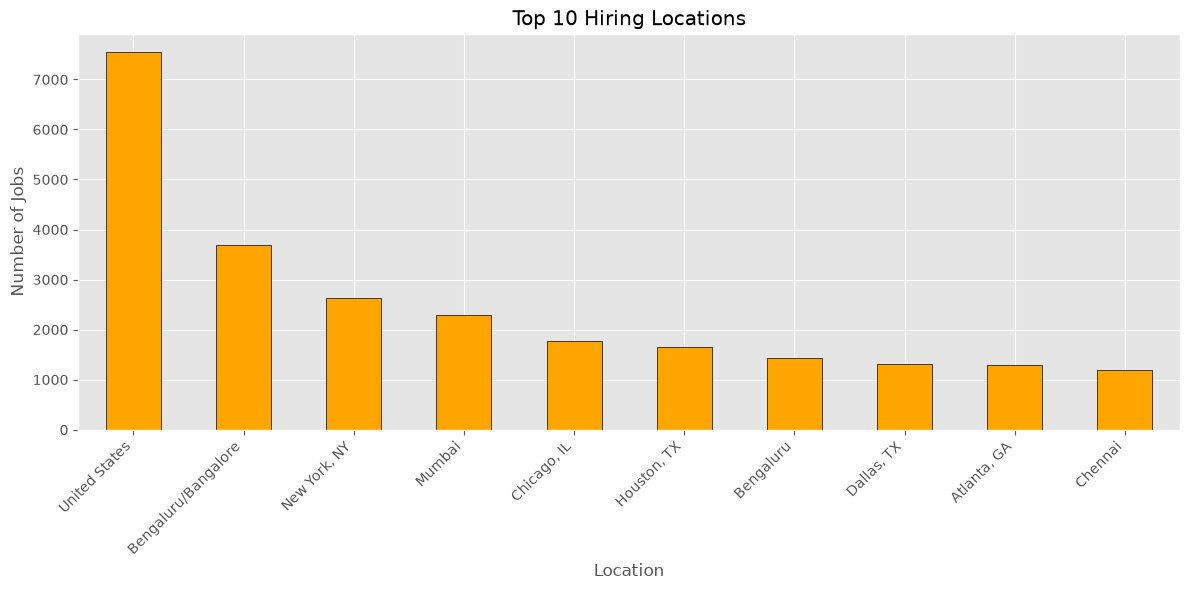

In [13]:
plt.figure(figsize=(12,6))

top_locations.plot(
    kind="bar",
    color="orange",
    edgecolor="black"
)

plt.title("Top 10 Hiring Locations")
plt.xlabel("Location")
plt.ylabel("Number of Jobs")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.show()

In [14]:
# ============================================================
# Experience Distribution
# ============================================================

experience_counts = jobs_df["experience"].value_counts()

display(experience_counts.head(15))

experience
Mid-Senior level    38901
Entry level         33764
Associate            9316
Director             3567
2 - 7 yrs            1666
Internship           1353
2 - 5 yrs            1186
Executive            1174
3 - 8 yrs            1164
3 - 5 yrs            1148
5 - 10 yrs           1061
1 - 3 yrs             713
2 - 4 yrs             703
4 - 9 yrs             697
0 - 5 yrs             640
Name: count, dtype: int64

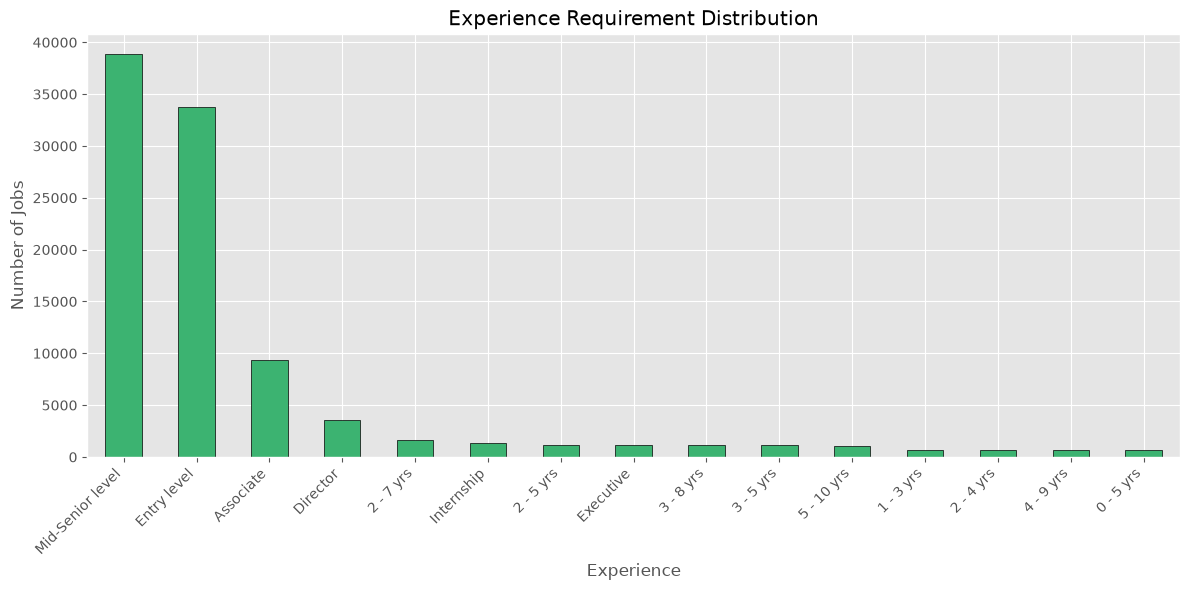

In [15]:
plt.figure(figsize=(12,6))

experience_counts.head(15).plot(
    kind="bar",
    color="mediumseagreen",
    edgecolor="black"
)

plt.title("Experience Requirement Distribution")
plt.xlabel("Experience")
plt.ylabel("Number of Jobs")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.show()

In [16]:
# ============================================================
# Most Common Skills
# ============================================================

all_skills = (
    jobs_df["skills"]
    .dropna()
    .str.split(",")
    .explode()
    .str.strip()
)

top_skills = all_skills.value_counts().head(20)

display(top_skills)

skills
Information Technology                   23784
Sales                                    22780
Management                               19006
Manufacturing                            16587
Health Care Provider                     14509
Business Development                     12320
Engineering                              11864
Other                                    11512
Finance                                   7630
Marketing                                 5921
IT Software - Application Programming     5756
Accounting/Auditing                       4728
Administrative                            4523
Customer Service                          3875
Project Management                        3685
Analyst                                   3573
Research                                  2784
Human Resources                           2482
Design                                    2358
Legal                                     2185
Name: count, dtype: int64

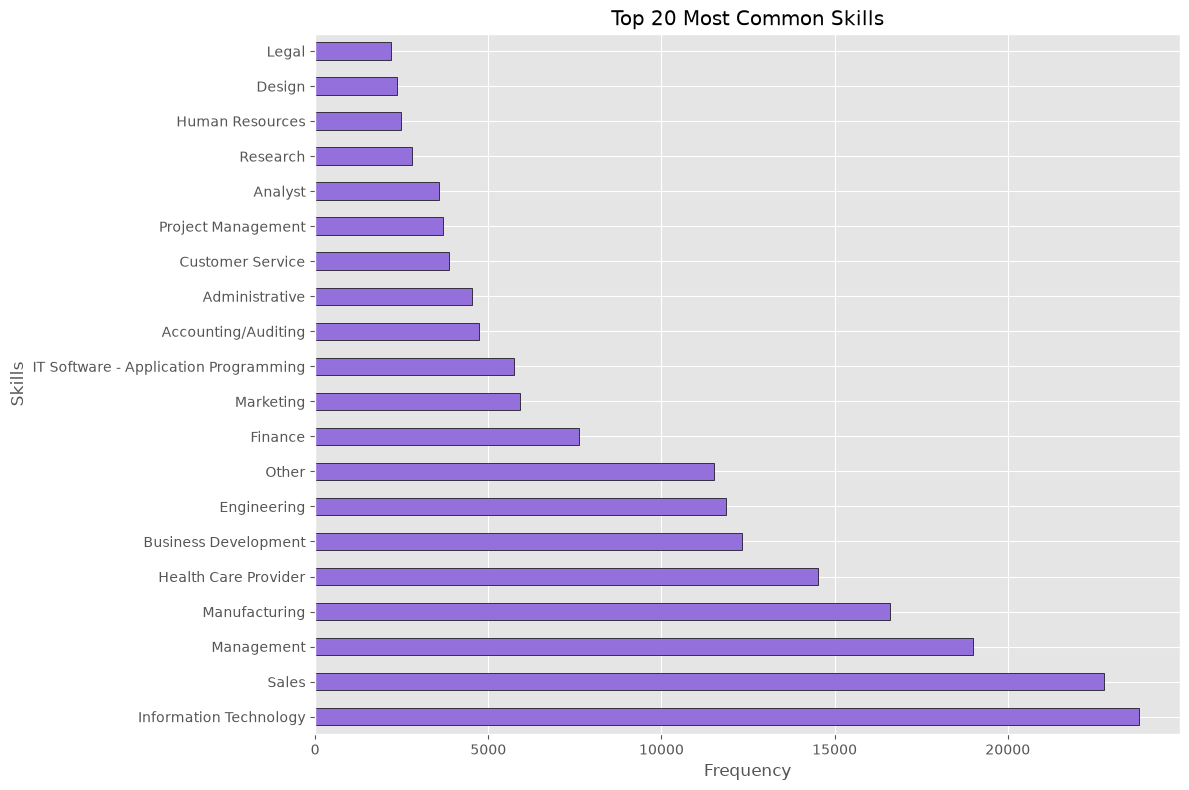

In [17]:
plt.figure(figsize=(12,8))

top_skills.plot(
    kind="barh",
    color="mediumpurple",
    edgecolor="black"
)

plt.title("Top 20 Most Common Skills")
plt.xlabel("Frequency")
plt.ylabel("Skills")

plt.tight_layout()

plt.show()

# EDA Summary

### Key Insights

- The resume dataset contains 25 job categories suitable for supervised classification.
- Resume lengths vary, indicating diverse document sizes.
- The jobs dataset contains over 136,000 job postings from many companies and locations.
- A few companies contribute a large share of job postings.
- Job opportunities are concentrated in specific locations.
- Frequently occurring skills indicate current industry demand.

The insights obtained from this analysis will guide feature engineering and model development in the next notebook.